Used PowerTransformer (Yeo-Johnson)


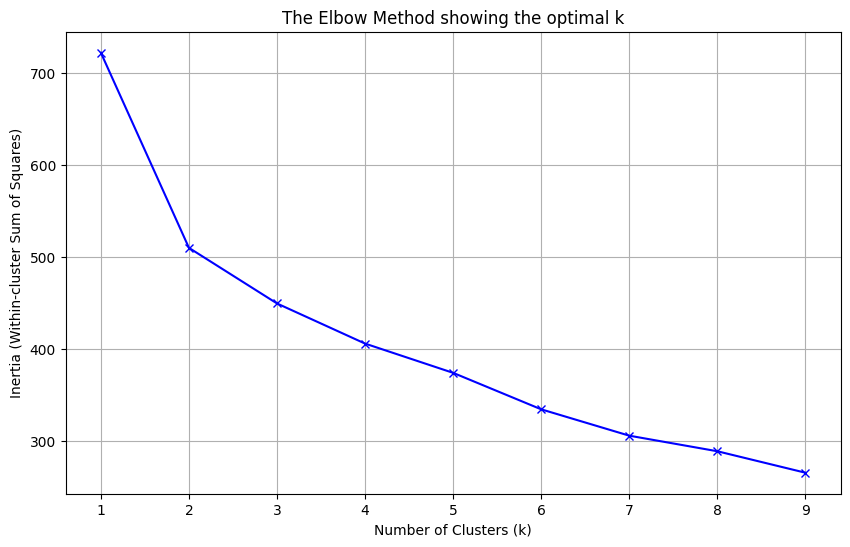

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PowerTransformer
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('../..', '..'))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Get the  unscaled data
# Can specify which method to use in the preprocess_dataset function: 'standard' or 'power'
X_scaled = preprocess_dataset('../../../data/processed/cleaned_feature_matrix.csv',
                             '../../../data/processed/cleaned_and_scaled.csv',
                             method='power')


# Calculate Inertia for different 'K' values
# Inertia is the sum of squared distances of samples to their closest cluster center.

inertia = []
K_range = range(1, 10) # Testing 1 to 9 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

# The K graph

at k=2 the returns start to diminish. but 2 clusters would likely be a bit boring
at k=3 and k=4 there may still be some interesting stuff... Going to test


# K=4

In [8]:
from sklearn.cluster import KMeans

df_averaged = pd.read_csv('../../data/processed/final_feature_matrix.csv')


# Run the final K-Means with k=4
# Using random_state=42 for reproducibility and n_init=10 for better convergence
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back
# (Use df_averaged so we can read the country names)
df_averaged['cluster'] = clusters

# Print the Archetypes
print("--- Climate Policy Archetypes (k=4) ---")
for i in range(4):
    countries = df_averaged[df_averaged['cluster'] == i]['Name'].tolist()
    print(f"\nArchetype {i}:")
    print(f"  Countries: {', '.join(countries)}")

--- Climate Policy Archetypes (k=4) ---

Archetype 0:
  Countries: Canada, Denmark, Finland, France, United Kingdom, Ireland, Norway, New Zealand, Sweden

Archetype 1:
  Countries: Australia, China, Czech Republic, Hungary, Israel, Japan, Korea, Republic of, Poland, Russian Federation, Saudi Arabia

Archetype 2:
  Countries: Argentina, Colombia, Indonesia, India, Mexico, Peru, Turkey, South Africa

Archetype 3:
  Countries: Austria, Belgium, Switzerland, Chile, Germany, Spain, Greece, Italy, Netherlands, Portugal, Slovakia


In [21]:
# Identify the most important columns to check
check_cols = ['gdp_per_capita_constant', 'coal_electricity_pct', 'renewable_electricity_pct', 'nd_gain_score', 'LEV3_NZ', 'LEV4_EE_MANDATE']

# Calculate the mean for each cluster
archetype_signatures = df_averaged.groupby('cluster')[check_cols].mean()

# Sort by GDP to see if it's just a wealth ranking
print(archetype_signatures.sort_values(by='gdp_per_capita_constant', ascending=False))

         gdp_per_capita_constant  coal_electricity_pct  \
cluster                                                  
0                   52520.462474              7.789959   
1                   34607.899351             16.259819   
2                   28736.208546             38.653638   
3                    7585.283417             38.180901   

         renewable_electricity_pct  nd_gain_score   LEV3_NZ  LEV4_EE_MANDATE  
cluster                                                                       
0                        23.565102      70.599267  5.151042         4.208333  
1                        20.033734      63.617234  2.958333         6.512821  
2                         6.163493      63.190806  0.463542         5.020833  
3                         5.099919      48.821060  0.976852         4.537037  


# K=3

In [9]:
from sklearn.cluster import KMeans

df_averaged = pd.read_csv('../../data/processed/final_feature_matrix.csv')
X_scaled = pd.read_csv('../../data/processed/merged_dataset_scaled.csv')


# Run the final K-Means with k=3
# Using random_state=42 for reproducibility and n_init=10 for better convergence
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back
# (Use df_averaged so we can read the country names)
df_averaged['cluster'] = clusters

# Print the Archetypes
print("--- Climate Policy Archetypes (k=3) ---")
for i in range(3):
    countries = df_averaged[df_averaged['cluster'] == i]['Name'].tolist()
    print(f"\nArchetype {i}:")
    print(f"  Countries: {', '.join(countries)}")

--- Climate Policy Archetypes (k=3) ---

Archetype 0:
  Countries: Austria, Canada, Switzerland, Germany, Denmark, Finland, France, United Kingdom, Ireland, Norway, New Zealand, Portugal, Sweden

Archetype 1:
  Countries: Australia, Belgium, China, Czech Republic, Spain, Greece, Hungary, Israel, Italy, Korea, Republic of, Netherlands, Poland, Russian Federation, Saudi Arabia, Slovakia

Archetype 2:
  Countries: Argentina, Chile, Colombia, Indonesia, India, Japan, Mexico, Peru, Turkey, South Africa


# K=2

In [5]:
from sklearn.cluster import KMeans

df_averaged = pd.read_csv('../../data/processed/final_feature_matrix.csv')


# Run the final K-Means with k=2
# Using random_state=42 for reproducibility and n_init=10 for better convergence
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back
# (Use df_averaged so we can read the country names)
df_averaged['cluster'] = clusters

# Print the Archetypes
print("--- Climate Policy Archetypes (k=2) ---")
for i in range(2):
    countries = df_averaged[df_averaged['cluster'] == i]['Name'].tolist()
    print(f"\nArchetype {i}:")
    print(f"  Countries: {', '.join(countries)}")

--- Climate Policy Archetypes (k=2) ---

Archetype 0:
  Countries: Austria, Belgium, Canada, Switzerland, Chile, Germany, Denmark, Spain, Finland, France, United Kingdom, Ireland, Italy, Netherlands, Norway, New Zealand, Portugal, Sweden

Archetype 1:
  Countries: Argentina, Australia, China, Colombia, Czech Republic, Greece, Hungary, Indonesia, India, Israel, Japan, Korea, Republic of, Mexico, Peru, Poland, Russian Federation, Saudi Arabia, Slovakia, Turkey, South Africa


# K=6

In [25]:
from sklearn.cluster import KMeans

df_averaged = pd.read_csv('../../data/processed/final_feature_matrix.csv')
X_scaled = pd.read_csv('../../data/processed/merged_dataset_scaled.csv')


# Run the final K-Means with k=6
# Using random_state=42 for reproducibility and n_init=10 for better convergence
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back
# (Use df_averaged so we can read the country names)
df_averaged['cluster'] = clusters

# Print the Archetypes
print("--- Climate Policy Archetypes (k=6) ---")
for i in range(6):
    countries = df_averaged[df_averaged['cluster'] == i]['Name'].tolist()
    print(f"\nArchetype {i}:")
    print(f"  Countries: {', '.join(countries)}")

--- Climate Policy Archetypes (k=6) ---

Archetype 0:
  Countries: Denmark, New Zealand

Archetype 1:
  Countries: Australia, Belgium, Czech Republic, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia

Archetype 2:
  Countries: Austria, Switzerland, Chile, Germany, Spain, United Kingdom, Greece, Hungary, Italy, Netherlands, Slovakia

Archetype 3:
  Countries: Canada, Finland, France, Ireland, Norway, Portugal, Sweden

Archetype 4:
  Countries: China, Indonesia, India, Turkey

Archetype 5:
  Countries: Argentina, Colombia, Japan, Mexico, Peru, South Africa
